# Zweiter Versuch: Skript fürs Training eines RL-Agenten zur Auftragssteuerung
## Hier: Schritt 1c, finetuning, trainiere das agv so, dass es sinnvolle Routen fährt
## Besonderheit hier: Die Befehle des AGV werden vorgefiltert, so dass fast nur sinnige Fahrten unternommen werden.
## Dann erst: Trainiere den Lager-Agenten, dass er sinnig auflädt unter der Annahme, dass das agv sinnige Routen fährt.

Der state wird für das AGV neu definiert, alles soll OHE sein:
4:  Erste vier Einträge: Anzahl geladener Waren OHE (0-4, wenn alle 4 Null dann logischerweise 0)
13: Die nächsten 13 Einträge OHE Standort AGV
4: Dann 4 Einträge, wieviel Waren an der Teststation abgeholt werden müssen, OHE (0-4, wenn alle 4 Null dann logischerweise 0)
13: Dann 13 Einträge als OHE-Maske, welche Stationen sinnvoll sind anzufahren (nach heuristischer Methodik: Nur die Stationen für die etwas geladen ist bzw. die Teststation nur dann, wenn genügend Platz für alle(!) abzuholenden Waren zur Verfügung steht).

In [1]:
import csv
import random
import numpy as np

##### Settting parameters ####

In [2]:
import factory_environment as env
import agv
import logic
import game_mechanics_4_agv_training as gm
import RL_Agent

In [3]:
my_env = env.env('ttable.csv', 'station_number.csv', 'env_control_order.csv')

In [4]:
my_agv = agv.agv()

In [5]:
my_logic = logic.logic()

In [6]:
gm = gm.game_mechanics(my_logic, my_env, my_agv)


## ⚙️ Reinforcement Learning Agent Parameters Explained

### 1. **gamma (γ) – Discount Factor**
- **Purpose**: Controls how much the agent values future rewards versus immediate ones.
- **Range**: Between 0 and 1.
- **Example**:
  - `γ = 0.99` → agent cares a lot about long-term rewards.
  - `γ = 0.1` → agent focuses mostly on immediate results.
- **Effect**: Higher values encourage farsightedness; lower values make the agent more short-term reactive.

---

### 2. **epsilon (ε) – Exploration Rate**
- **Purpose**: Determines the probability of the agent choosing a **random action** (exploration) versus the **best-known action** (exploitation).
- **Range**: Between 0 and 1.
- **Behavior**:
  - `ε = 1.0` → pure exploration (tries everything).
  - `ε = 0.01` → mostly exploits learned policy.
- **Why It Matters**: Without exploration, the agent might miss better strategies.

---

### 3. **epsilon_min**
- **Purpose**: Minimum bound for `epsilon` during training.
- **Prevents**: The agent from becoming completely deterministic too early.
- **Example**: `epsilon_min = 0.01` → agent will always have a 1% chance of trying something new.

---

### 4. **epsilon_decay**
- **Purpose**: Determines how quickly the `epsilon` value decays over time.
- **Example**:
  - `epsilon *= 0.995` per episode → slow decay.
  - `epsilon *= 0.9` → faster decay.
- **Goal**: Start explorative and gradually become confident in its knowledge.

---

### 5. **learning_rate (α)**
- **Purpose**: Determines how much new knowledge overrides old Q-values during updates.
- **Range**: Small positive float, like `0.001`.
- **Trade-off**:
  - High value: Learns fast, might oscillate or forget.
  - Low value: Stable but slow learning.

---

### 6. **memory (Replay Buffer)**
- **Type**: `deque` (double-ended queue) storing past experiences.
- **Why**: Helps decorrelate experiences for better training stability.
- **Stored Values**: Each memory is a tuple of `(state, action, reward, next_state, done)`.

---

### 7. **batch_size**
- **Purpose**: Number of experiences randomly sampled from memory to train on each time.
- **Effect**:
  - Small batch → more frequent updates, less stable.
  - Large batch → more stable updates, slower cycles.

---

### 8. **state_size**
- **What**: Number of features that describe the current environment state.
- **Use**: Defines the input shape of your neural network.

### 9. **action_size**
- **What**: Number of possible actions the agent can take.
- **Use**: Defines the output shape of your neural network.

---

Let me know if you'd like a cheat sheet summarizing this, or if you’re curious about how these interact during training. We can also dive deeper into things like target networks or dueling architectures when you're ready to advance! 🧠✨

In [7]:
START_POS = 1   # Startet an Lager B

### Sonstige Training-Variablen
MAX_TIME_ONE_GAME = 3600*4
GAMES_PER_EPISODE = 8
GAMES_REPLAY = 1
EPISODE_COUNT = 150

#### Action size
# Fahre zu einer der 13 Stationen
action_size_agv = 13


#### Variablen für RL-Agent
GAMMA = 0.95  #0.99
EPSILON = 0.4 
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995
LEARNING_RATE = 0.0002
BATCH_SIZE = 128


In [8]:
loading = 'models/agv_V7.keras'
my_RL_agent_agv = RL_Agent.DQNAgent(len(gm.act_state), action_size_agv, GAMMA, EPSILON, EPSILON_MIN, EPSILON_DECAY, LEARNING_RATE, loading)
my_RL_agent_agv.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,737 (178.66 KB)

 Trainable params: 15,245 (59.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,492 (119.11 KB)

In [9]:
######
reward_vec = []
total_time_vec = []
tracker_vec = []
points_vec = []  # ← NEU

gm.reset()
my_env.reset()
my_agv.reset()

for episode in range(EPISODE_COUNT):
    for game in range(GAMES_PER_EPISODE):
        total_reward, total_time, tracker = gm.run_game(my_RL_agent_agv)
        reward_vec.append(total_reward)
        total_time_vec.append(total_time)
        tracker_vec.append(tracker)
        points_vec.append(gm.points)
        
        my_env.reset()    
        my_agv.reset()
        gm.reset()
        
        # Replay nach jedem Spiel
        my_RL_agent_agv.replay(BATCH_SIZE)
    
    # Periodisches Speichern
    if episode % 100 == 0 and episode > 0:
        my_RL_agent_agv.model.save(f'./models/agv_V7Basis_ep{episode}.keras')
    
    if episode %20== 0:
        print(f'Episode {episode}, epsilon: {my_RL_agent_agv.epsilon:.3f}')
        print(f'  Mean reward (last 40): {np.mean(reward_vec[-40:]):.2f}')
        print(f'  Mean time (last 40):   {np.mean(total_time_vec[-40:]):.0f}s')

Episode 0, epsilon: 0.400
  Mean reward (last 40): -11.69
  Mean time (last 40):   2721s
Episode 20, epsilon: 0.179
  Mean reward (last 40): -9.77
  Mean time (last 40):   2337s
Episode 40, epsilon: 0.080
  Mean reward (last 40): -8.89
  Mean time (last 40):   2129s
Episode 60, epsilon: 0.050
  Mean reward (last 40): -8.88
  Mean time (last 40):   2129s
Episode 80, epsilon: 0.050
  Mean reward (last 40): -8.98
  Mean time (last 40):   2147s
Episode 100, epsilon: 0.050
  Mean reward (last 40): -8.62
  Mean time (last 40):   2065s
Episode 120, epsilon: 0.050
  Mean reward (last 40): -8.89
  Mean time (last 40):   2127s
Episode 140, epsilon: 0.050
  Mean reward (last 40): -8.53
  Mean time (last 40):   2055s


In [10]:
'''######
reward_vec = []
total_time_vec = []
tracker_vec = []
points_vec = []  # ← NEU

gm.reset()
my_env.reset()
my_agv.reset()
for episode in range(EPISODE_COUNT):
    for game in range(GAMES_PER_EPISODE):
        for replays in range(GAMES_REPLAY):
            total_reward, total_time, tracker = gm.run_game(my_RL_agent_agv)
            reward_vec.append(total_reward)
            total_time_vec.append(total_time)
            tracker_vec.append(tracker)
            points_vec.append(gm.points)  # ← NEU
            my_env.reset()    
            my_agv.reset()
            gm.reset()        
        my_env.reset()
        gm.reset()
        #my_agv.reset()
    my_RL_agent_agv.replay(BATCH_SIZE)

    # Periodisch speichern (alle 20 Episoden)
    if episode % 20 == 0 and episode > 0:
        my_RL_agent_agv.model.save(f'./models/agv_ep{episode}.keras')

    if episode % 5 == 0:
        print(f'epsilon was: {my_RL_agent_agv.epsilon}')
        print(f'mean reward episode {episode}: {np.mean(reward_vec[:-GAMES_PER_EPISODE+1])}')
        print(f'mean total time: {np.mean(total_time_vec[:-GAMES_PER_EPISODE+1])}')
    my_RL_agent_agv.epsilon *=EPSILON_DECAY'''
    
        

"######\nreward_vec = []\ntotal_time_vec = []\ntracker_vec = []\npoints_vec = []  # ← NEU\n\ngm.reset()\nmy_env.reset()\nmy_agv.reset()\nfor episode in range(EPISODE_COUNT):\n    for game in range(GAMES_PER_EPISODE):\n        for replays in range(GAMES_REPLAY):\n            total_reward, total_time, tracker = gm.run_game(my_RL_agent_agv)\n            reward_vec.append(total_reward)\n            total_time_vec.append(total_time)\n            tracker_vec.append(tracker)\n            points_vec.append(gm.points)  # ← NEU\n            my_env.reset()    \n            my_agv.reset()\n            gm.reset()        \n        my_env.reset()\n        gm.reset()\n        #my_agv.reset()\n    my_RL_agent_agv.replay(BATCH_SIZE)\n\n    # Periodisch speichern (alle 20 Episoden)\n    if episode % 20 == 0 and episode > 0:\n        my_RL_agent_agv.model.save(f'./models/agv_ep{episode}.keras')\n\n    if episode % 5 == 0:\n        print(f'epsilon was: {my_RL_agent_agv.epsilon}')\n        print(f'mean rewa

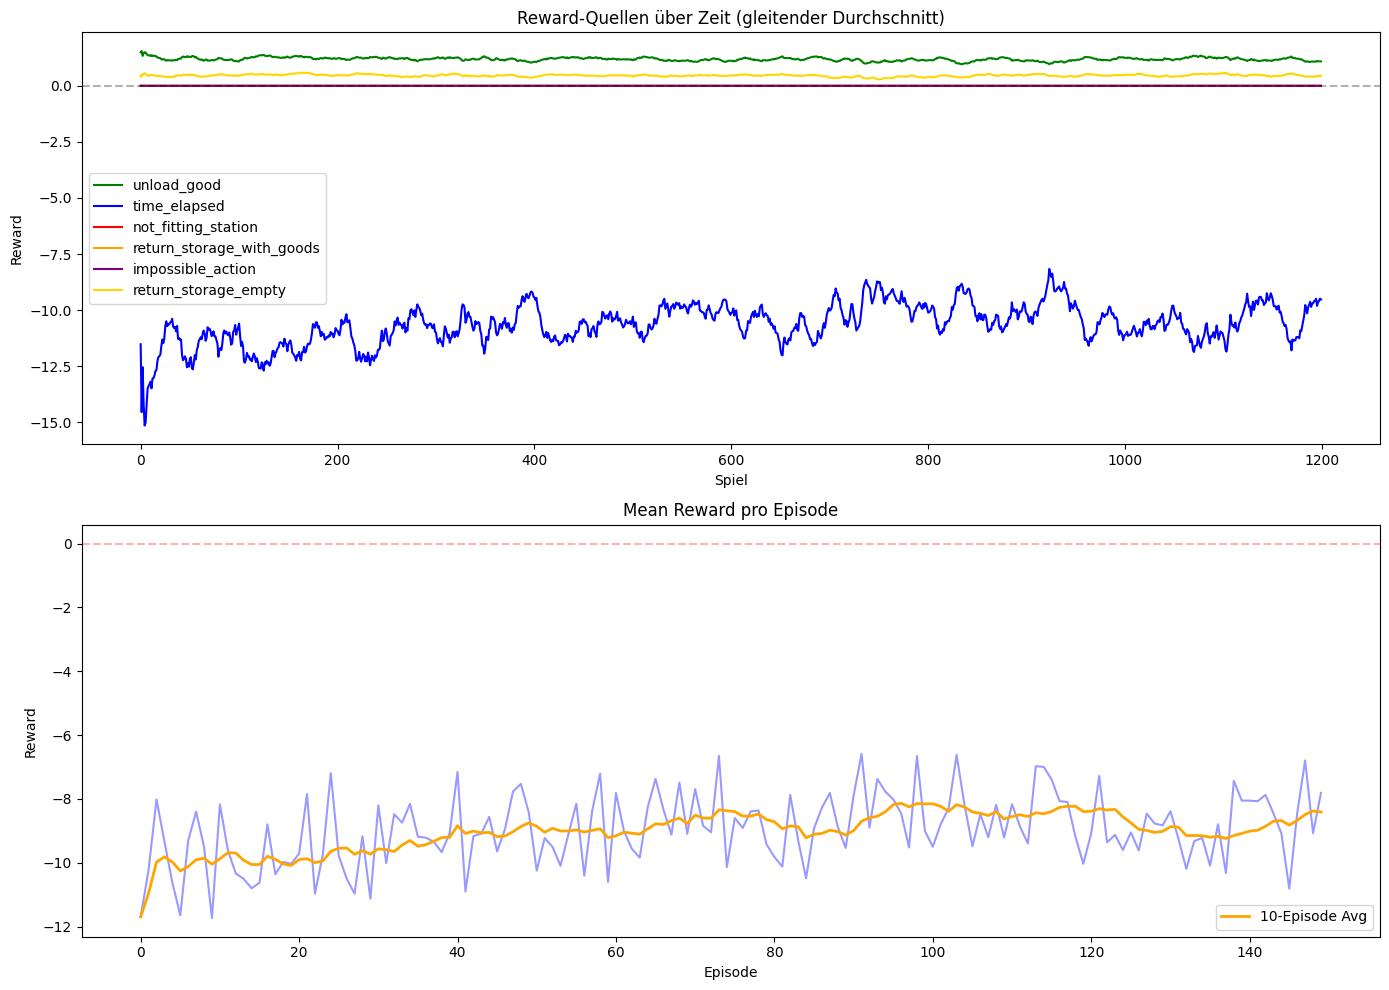


Durchschnitt pro Spiel:
  unload_good                   : +1.186
  time_elapsed                  : -10.603
  not_fitting_station           : +0.000
  return_storage_with_goods     : +0.000
  impossible_action             : +0.000
  return_storage_empty          : +0.460


In [11]:
import matplotlib.pyplot as plt
import numpy as np

window = 20
keys = ['unload_good', 'time_elapsed', 'not_fitting_station', 
        'return_storage_with_goods', 'impossible_action', 'return_storage_empty']
colors = ['green', 'blue', 'red', 'orange', 'purple', 'gold']

plt.figure(figsize=(14, 10))

# Plot 1: Gleitender Durchschnitt
plt.subplot(2, 1, 1)
for key, color in zip(keys, colors):
    values = [t[key] for t in tracker_vec]
    moving_avg = [np.mean(values[max(0,i-window):i+1]) 
                  for i in range(len(values))]
    plt.plot(moving_avg, label=key, color=color)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Reward-Quellen über Zeit (gleitender Durchschnitt)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.legend()

# Plot 2: Mean Reward pro Episode
plt.subplot(2, 1, 2)
mean_reward_per_episode = [np.mean(reward_vec[i:i+GAMES_PER_EPISODE]) 
                           for i in range(0, len(reward_vec), GAMES_PER_EPISODE)]
plt.plot(mean_reward_per_episode, color='blue', alpha=0.4)
moving_avg_ep = [np.mean(mean_reward_per_episode[max(0,i-10):i+1]) 
                 for i in range(len(mean_reward_per_episode))]
plt.plot(moving_avg_ep, color='orange', linewidth=2, label='10-Episode Avg')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title("Mean Reward pro Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()

plt.tight_layout()
plt.show()

print("\nDurchschnitt pro Spiel:")
for key in keys:
    values = [t[key] for t in tracker_vec]
    print(f"  {key:30s}: {np.mean(values):+.3f}")

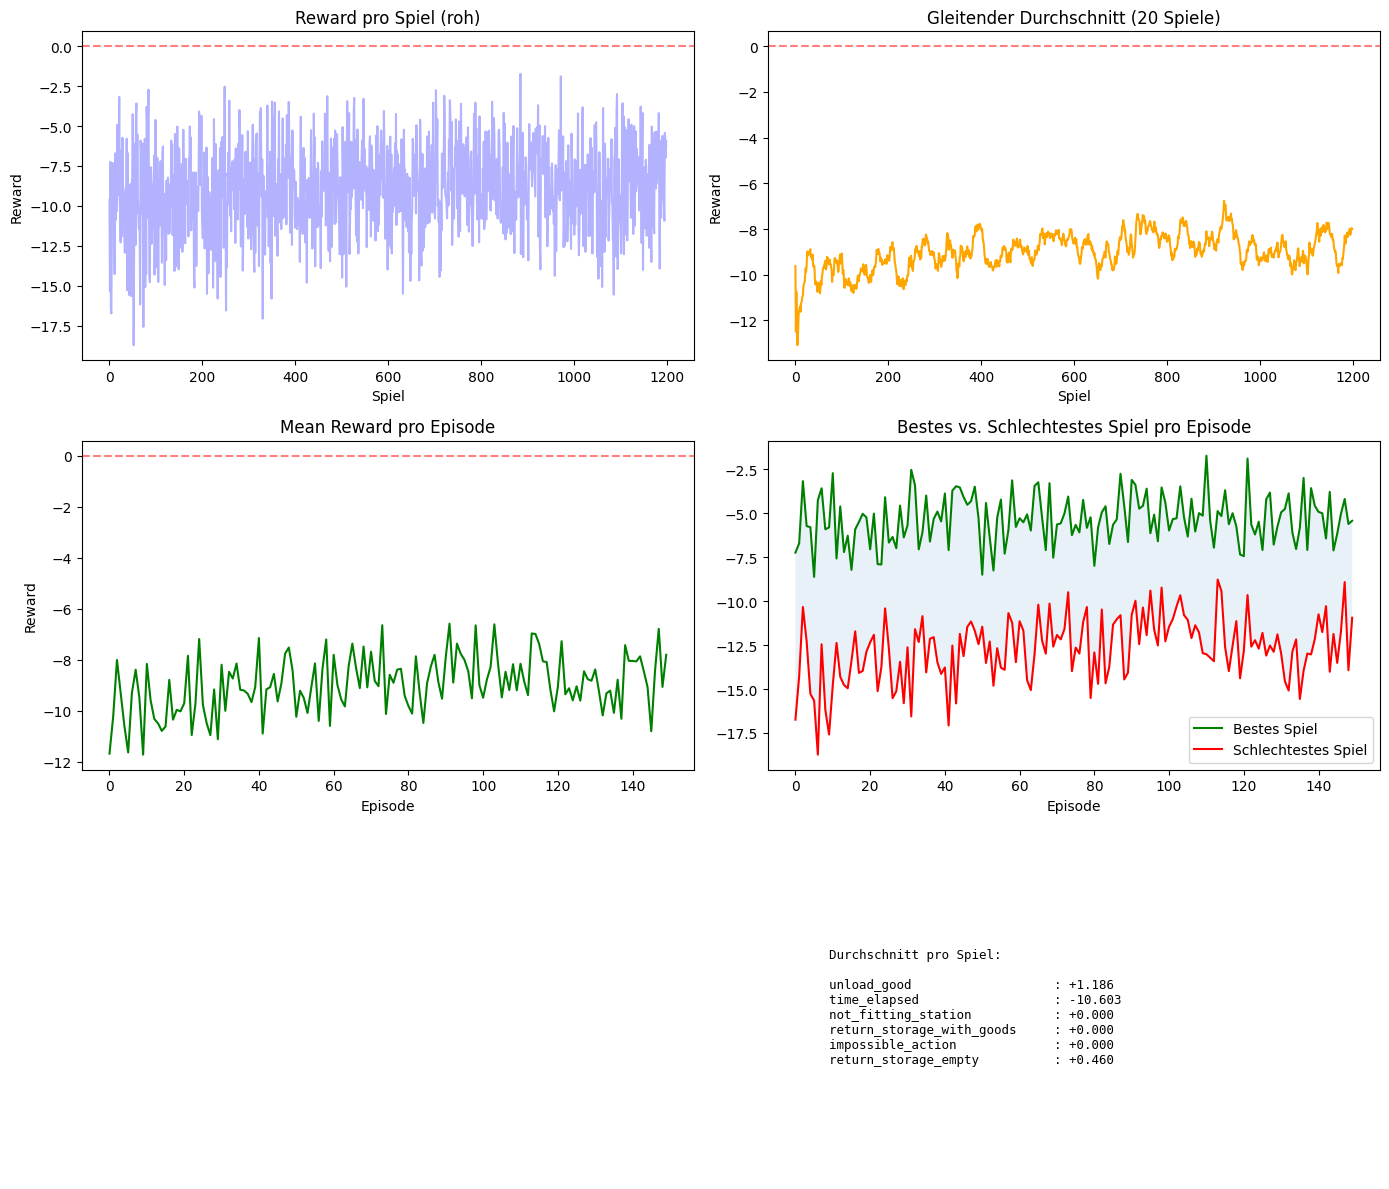

In [12]:
import matplotlib.pyplot as plt
import numpy as np

window = 20
keys = ['unload_good', 'time_elapsed', 'not_fitting_station', 
        'return_storage_with_goods', 'impossible_action', 'return_storage_empty']
colors = ['green', 'blue', 'red', 'orange', 'purple', 'gold']

plt.figure(figsize=(14, 12))

# 1. Reward-Verlauf roh
plt.subplot(3, 2, 1)
plt.plot(reward_vec, alpha=0.3, color='blue')
plt.title("Reward pro Spiel (roh)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 2. Gleitender Durchschnitt
plt.subplot(3, 2, 2)
moving_avg = [np.mean(reward_vec[max(0,i-window):i+1]) 
              for i in range(len(reward_vec))]
plt.plot(moving_avg, color='orange')
plt.title(f"Gleitender Durchschnitt ({window} Spiele)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. Mean Reward pro Episode
plt.subplot(3, 2, 3)
plt.plot(mean_reward_per_episode, color='green')
plt.title("Mean Reward pro Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 4. Bestes vs. Schlechtestes Spiel
plt.subplot(3, 2, 4)
best_per_ep = [max(reward_vec[i:i+GAMES_PER_EPISODE]) 
               for i in range(0, len(reward_vec), GAMES_PER_EPISODE)]
worst_per_ep = [min(reward_vec[i:i+GAMES_PER_EPISODE]) 
                for i in range(0, len(reward_vec), GAMES_PER_EPISODE)]
plt.plot(best_per_ep, color='green', label='Bestes Spiel')
plt.plot(worst_per_ep, color='red', label='Schlechtestes Spiel')
plt.fill_between(range(len(best_per_ep)), worst_per_ep, best_per_ep, alpha=0.1)
plt.title("Bestes vs. Schlechtestes Spiel pro Episode")
plt.xlabel("Episode")
plt.legend()

# 6. Durchschnittswerte Text
plt.subplot(3, 2, 6)
plt.axis('off')
text = "Durchschnitt pro Spiel:\n\n"
for key in keys:
    values = [t[key] for t in tracker_vec]
    text += f"{key:30s}: {np.mean(values):+.3f}\n"
plt.text(0.1, 0.5, text, fontsize=9, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

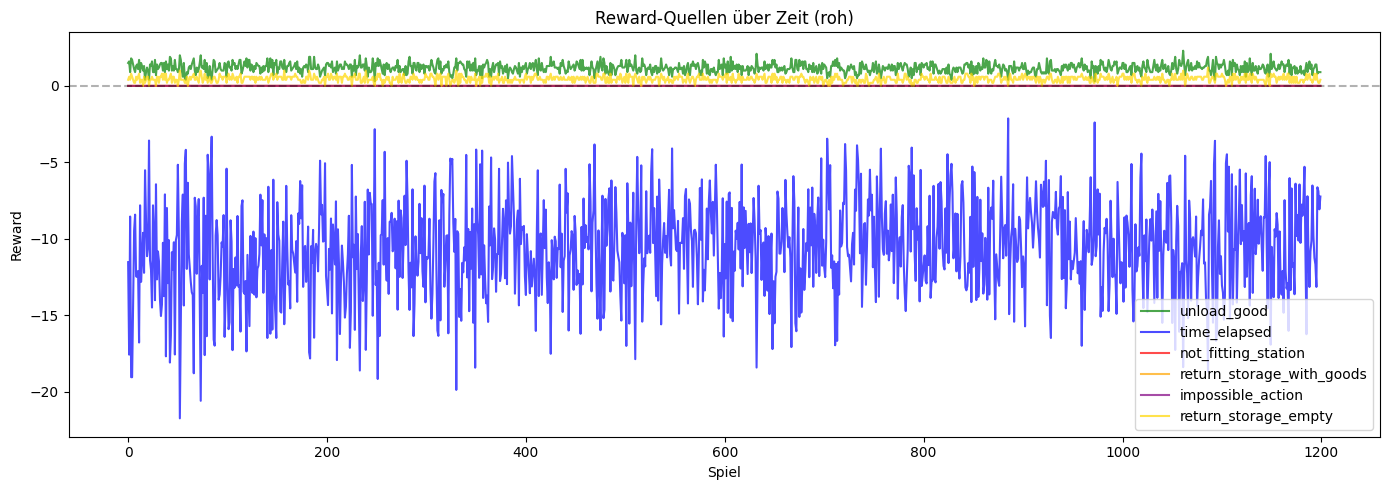

In [13]:
import matplotlib.pyplot as plt
import numpy as np

keys = ['unload_good', 'time_elapsed', 'not_fitting_station', 
        'return_storage_with_goods', 'impossible_action', 'return_storage_empty']
colors = ['green', 'blue', 'red', 'orange', 'purple', 'gold']

plt.figure(figsize=(14, 5))

for key, color in zip(keys, colors):
    values = [t[key] for t in tracker_vec]
    plt.plot(values, label=key, color=color, alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title("Reward-Quellen über Zeit (roh)")
plt.xlabel("Spiel")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

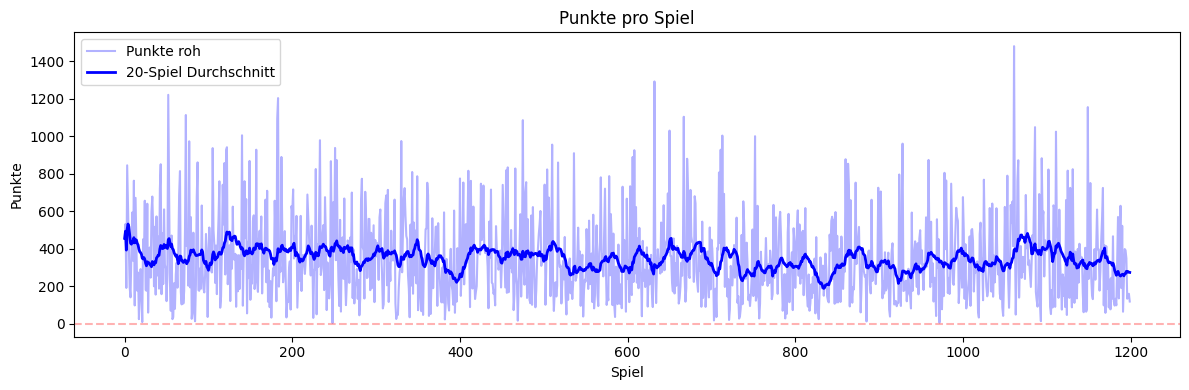

Durchschnitt: 346.35
Bestes Spiel: 1481.49
Letztes Spiel: 117.81


In [14]:
import matplotlib.pyplot as plt
import numpy as np

window = 20
moving_avg = [np.mean(points_vec[max(0,i-window):i+1]) 
              for i in range(len(points_vec))]

plt.figure(figsize=(12, 4))
plt.plot(points_vec, alpha=0.3, color='blue', label='Punkte roh')
plt.plot(moving_avg, color='blue', linewidth=2, label=f'{window}-Spiel Durchschnitt')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title("Punkte pro Spiel")
plt.xlabel("Spiel")
plt.ylabel("Punkte")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Durchschnitt: {np.mean(points_vec):.2f}")
print(f"Bestes Spiel: {max(points_vec):.2f}")
print(f"Letztes Spiel: {points_vec[-1]:.2f}")

In [15]:
print(f'mittlere Belohnung für die ersten 100 Spiele: {np.mean(reward_vec[0:100])}')
print(f'mittlere Belohnung für die letzten 100 Spiele: {np.mean(reward_vec[:-100])}')
print(f'Abschließendes epsilon: {my_RL_agent_agv.epsilon}')

mittlere Belohnung für die ersten 100 Spiele: -9.833156518747849
mittlere Belohnung für die letzten 100 Spiele: -9.000678409481814
Abschließendes epsilon: 0.049961848807990636


In [16]:
mean_reward_per_episode = []
for i in range(0,len(reward_vec),GAMES_PER_EPISODE):
    if i % GAMES_PER_EPISODE == 0:
        mean_reward_per_episode.append(np.mean(reward_vec[i:i+GAMES_PER_EPISODE]))
   

In [17]:
#my_RL_agent_agv.model.save('model_agv.h5')

In [18]:
import os

base_path = './models/agv_V'
version = 1
while os.path.exists(f'{base_path}{version}.keras'):
    version += 1
my_RL_agent_agv.model.save(f'{base_path}{version}.keras')
print(f'Model saved as {base_path}{version}.keras')

Model saved as ./models/agv_V2.keras
